In [1]:
import scanpy as sc

adata = sc.read_h5ad(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad")

adata

AnnData object with n_obs × n_vars = 77668 × 33539
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pmito', 'n_genes', 'Condition', 'louvain', 'scv2+', 'louvain_res0.5', 'ctype_res0.5', 'ctype', 'subctype', 'init_ctype', 'scv2_5+', 'scv2_10+', 'raw', 'res_inf', 'ees_inf', 'Group', 'dpi', 'inf_scv2_5+', 'inf_scv2_10+', 'Viral_transcript'

In [16]:
print(adata.obs["Viral_transcript"].head(10))

AAACCCACAACCGCTG-1-1dpi_CoV2_HCR    0
AAACCCACAATTGAAG-1-1dpi_CoV2_HCR    0
AAACCCACACACAGAG-1-1dpi_CoV2_HCR    0
AAACCCACATCTAACG-1-1dpi_CoV2_HCR    2
AAACCCAGTCCCGGTA-1-1dpi_CoV2_HCR    0
AAACCCAGTTAGCGGA-1-1dpi_CoV2_HCR    0
AAACCCAGTTCGAAGG-1-1dpi_CoV2_HCR    0
AAACCCAGTTTCCAAG-1-1dpi_CoV2_HCR    0
AAACCCATCAGCACCG-1-1dpi_CoV2_HCR    0
AAACCCATCATCGGGC-1-1dpi_CoV2_HCR    0
Name: Viral_transcript, dtype: int64


In [8]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 224401902 stored elements and shape (77668, 33539)>

In [13]:
import pandas as pd

n_cell = 5
n_gene = 5

df = pd.DataFrame(
    adata.X[:n_cell, :n_gene].toarray(),
    index=adata.obs_names[:n_cell],      # 細胞名稱
    columns=adata.var_names[:n_gene]    # 基因名稱
)

print(df)

                                  MIR1302-2HG  FAM138A  OR4F5  AL627309.1  \
AAACCCACAACCGCTG-1-1dpi_CoV2_HCR            0        0      0           0   
AAACCCACAATTGAAG-1-1dpi_CoV2_HCR            0        0      0           0   
AAACCCACACACAGAG-1-1dpi_CoV2_HCR            0        0      0           0   
AAACCCACATCTAACG-1-1dpi_CoV2_HCR            0        0      0           1   
AAACCCAGTCCCGGTA-1-1dpi_CoV2_HCR            0        0      0           0   

                                  AL627309.3  
AAACCCACAACCGCTG-1-1dpi_CoV2_HCR           0  
AAACCCACAATTGAAG-1-1dpi_CoV2_HCR           0  
AAACCCACACACAGAG-1-1dpi_CoV2_HCR           0  
AAACCCACATCTAACG-1-1dpi_CoV2_HCR           0  
AAACCCAGTCCCGGTA-1-1dpi_CoV2_HCR           0  


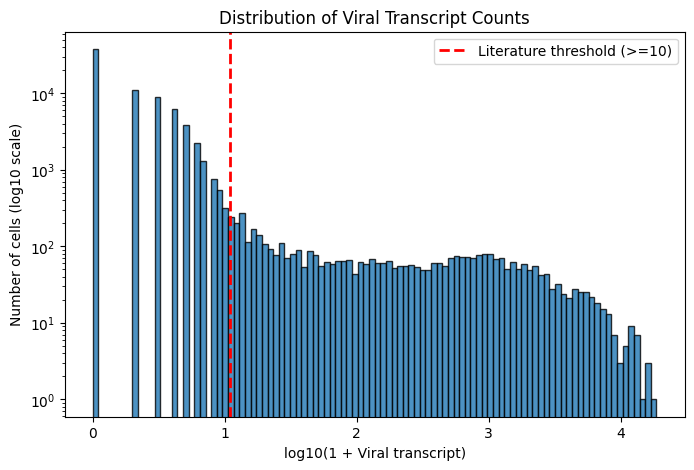

Total cells: 77668
Transcript counts = 0 :  37814
Transcript counts >=10: 4761
Percentage of >= 10: 6.129937683473245 %


In [70]:
import numpy as np
import matplotlib.pyplot as plt

viral = adata.obs["Viral_transcript"]

plt.figure(figsize=(8,5))

plt.hist(
    np.log10(viral+1),
    bins=100,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    np.log10(11),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Literature threshold (>=10)"
)

plt.yscale("log")      

plt.xlabel("log10(1 + Viral transcript)") # +1是為了避免原始為0，轉換完之後是-∞
plt.ylabel("Number of cells (log10 scale)")
plt.title("Distribution of Viral Transcript Counts")
plt.legend()

plt.show()

print("Total cells:", len(viral))
print("Transcript counts = 0 : ",len(viral[viral == 0]))
print("Transcript counts >=10:", len(viral[viral >= 10]))
print("Percentage of >= 10:", (viral >= 10).mean()*100,"%")

90th percentile: 1954.0
log10(90th percentile): 3.2909245593827543


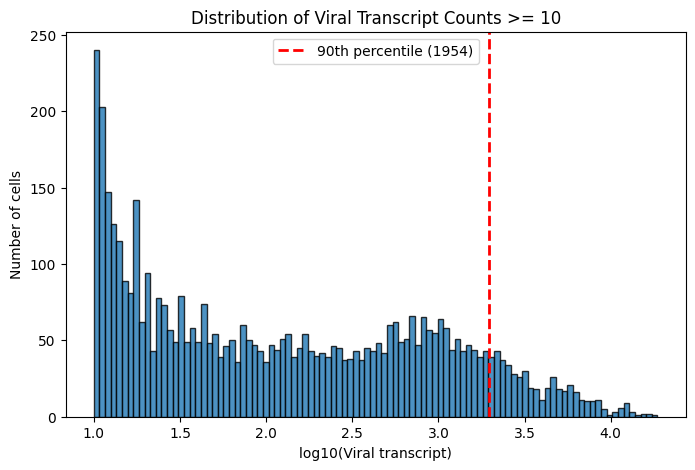

In [75]:
import numpy as np
import matplotlib.pyplot as plt

viral = adata.obs["Viral_transcript"]

viral_10 = viral[viral >= 10]

# 找90百分位數 (原始尺度)
p90 = np.percentile(viral_10, 90)

# 轉換到log10尺度
p90_log = np.log10(p90)

print("90th percentile:", p90)
print("log10(90th percentile):", p90_log)

plt.figure(figsize=(8,5))

plt.hist(
    np.log10(viral_10),
    bins=100,
    edgecolor="black",
    alpha=0.8
)

# 畫90百分位線
plt.axvline(
    p90_log,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"90th percentile ({p90:.0f})"
)

plt.xlabel("log10(Viral transcript)")
plt.ylabel("Number of cells")
plt.title("Distribution of Viral Transcript Counts >= 10")

plt.legend()

plt.show()

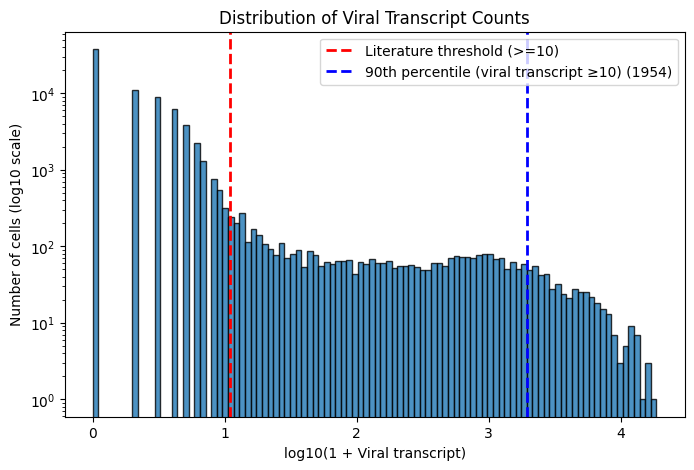

Total cells: 77668
Transcript counts = 0 : 37814
Transcript counts >= 10: 4761
Percentage of >= 10: 6.129937683473245 %
90th percentile (viral transcript ≥10): 1954
Transcript counts >= 1954: 477
Percentage of >= 1954: 0.614152546737395 %


In [87]:
import numpy as np
import matplotlib.pyplot as plt

viral = adata.obs["Viral_transcript"]

# candidate infected
viral_10 = viral[viral >= 10]

# 找 p90 (原始尺度)
p90 = np.percentile(viral_10, 90)

# 轉換到目前圖的 x 軸尺度
p90_log = np.log10(p90 + 1)

plt.figure(figsize=(8,5))

plt.hist(
    np.log10(viral + 1),
    bins=100,
    edgecolor="black",
    alpha=0.8
)

# 文獻 threshold >=10
plt.axvline(
    np.log10(11),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Literature threshold (>=10)"
)

# p90 threshold
plt.axvline(
    p90_log,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"90th percentile (viral transcript ≥10) ({p90:.0f})"
)

plt.yscale("log")

plt.xlabel("log10(1 + Viral transcript)")
plt.ylabel("Number of cells (log10 scale)")
plt.title("Distribution of Viral Transcript Counts")
plt.legend()

plt.show()

print("Total cells:", len(viral))
print("Transcript counts = 0 :", (viral == 0).sum())
print("Transcript counts >= 10:", (viral >= 10).sum())
print("Percentage of >= 10:", (viral >= 10).mean()*100, "%")
print("90th percentile (viral transcript ≥10):", int(p90))
print(f"Transcript counts >= {int(p90)}:", len(viral[viral >= p90]))
print(f"Percentage of >= {int(p90)}:",(viral >= p90).mean()*100, "%")


In [90]:
print(viral[viral >= p90].head())

AACAAGATCTTGCGCT-1-1dpi_CoV2_HCR    5511
AAGTGAAGTGCCTATA-1-1dpi_CoV2_HCR    4743
AAGTTCGGTTTGATCG-1-1dpi_CoV2_HCR    6162
ACAACCATCTTGATTC-1-1dpi_CoV2_HCR    8914
ACACAGTAGACCAGCA-1-1dpi_CoV2_HCR    4484
Name: Viral_transcript, dtype: int64


In [95]:
import numpy as np

positive_idx = np.where(viral >= p90)[0]
negative_idx = np.where(viral == 0)[0]

np.random.seed(42)

negative_sample_idx = np.random.choice(
    negative_idx,
    size=len(positive_idx)*3,
    replace=False
)

train_idx = np.concatenate([
    positive_idx,
    negative_sample_idx
])

In [101]:
# 高可信度感染細胞
adata_infected = adata[positive_idx].copy()

# 高可信度未感染細胞
adata_uninfected = adata[negative_sample_idx].copy()

# 未標籤細胞
unknown_idx = np.setdiff1d(
    np.arange(adata.n_obs),
    train_idx
)

adata_unknown = adata[unknown_idx].copy()

print("High-confidence infected:", adata_infected.n_obs)
print("High-confidence uninfected:", adata_uninfected.n_obs)
print("Unknown:", adata_unknown.n_obs)

High-confidence infected: 477
High-confidence uninfected: 1431
Unknown: 75760


In [ ]:
# 計算HVG

import scanpy as sc

adata_gcn = adata.copy()

# normalization
sc.pp.normalize_total(
    adata_gcn,
    target_sum=1e4
)

# log transformation
sc.pp.log1p(adata_gcn)

# HVG
sc.pp.highly_variable_genes(
    adata_gcn,
    n_top_genes=2000,
    flavor="seurat"
)

In [107]:
adata_gcn.var["highly_variable"].sum()

np.int64(2000)

In [108]:
adata_hvg = adata_gcn[
    :,
    adata_gcn.var.highly_variable
].copy()

sc.pp.scale(
    adata_hvg,
    max_value=10
)

sc.tl.pca(
    adata_hvg,
    n_comps=50
)

c:\Users\USER\miniconda3\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [109]:
X = adata_hvg.obsm["X_pca"]

print(X.shape)

(77668, 50)
